In [1]:
%pip install torch torchvision numpy matplotlib scikit-learn tqdm --index-url https://download.pytorch.org/whl/cu128

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu128
  Using cached https://download.pytorch.org/whl/cu128/torch-2.10.0%2Bcu128-cp312-cp312-win_amd64.whl.metadata (29 kB)
  Using cached https://download-r2.pytorch.org/whl/cu128/torchvision-0.25.0%2Bcu128-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached filelock-3.20.0-py3-none-any.whl.metadata (2.1 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached fsspec-2025.12.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/2.9 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 GB 87.8 MB/s eta 0:00:33
    --------------------------------------- 0.0/2.9 GB 93.2 MB/s eta 0:00:31
    --------------------------------------- 0.1/2.9 GB 91.4 MB/s eta 0:0

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\SSAFY\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import torch

In [3]:
torch.cuda.is_available()

True

In [4]:
torch.mps.is_available()

False

In [5]:
device = 'cpu'
# windows - cuda
if torch.cuda.is_available():
    device = torch.device('cuda')
# apple silicon - mps
if torch.mps.is_available():
    device = torch.device('mps')

# 난수 고정
import numpy as np
import random
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# windows - cuda
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# apple silicon - mps
if torch.mps.is_available():
    torch.mps.manual_seed(SEED)
    torch.use_deterministic_algorithms(True, warn_only=True)

In [6]:
"""
선형 회귀 모델을 PyTorch로 구현
"""
from torch import nn
from torch import optim

# 더미 데이터 생성
X = torch.linspace(0, 10, 100).unsqueeze(1)
y_true = 2 * X + 1 + 0.5 * torch.randn_like(X)

# 1차원 입력, 1차원 출력의 선형 모델을 만들것이다
model = nn.Linear(1, 1)
# 비용 함수는 MSE를 쓸거다
criterion = nn.MSELoss()
# SGD로 파라미러를 갱신할거다
optimizer = optim.SGD(model.parameters(), lr=0.01)

# 학습 시작
epochs = 200
for epoch in range(epochs):
    # 기울기 초기화
    optimizer.zero_grad()

    # 예측 진행
    y_pred = model(X)
    # 손실 계산
    loss = criterion(y_pred, y_true)
    # 비용의 미분 계산
    loss.backward()
    # 매개변수 업데이트
    optimizer.step()
    # 20번의 학습마다 기록
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

print('학습된 가중치 + 편향')
for name, param in model.named_parameters():
    print(f'{name}: {param.data}')


Epoch [20/200], Loss: 0.7862
Epoch [40/200], Loss: 0.6877
Epoch [60/200], Loss: 0.6071
Epoch [80/200], Loss: 0.5409
Epoch [100/200], Loss: 0.4867
Epoch [120/200], Loss: 0.4423
Epoch [140/200], Loss: 0.4060
Epoch [160/200], Loss: 0.3761
Epoch [180/200], Loss: 0.3517
Epoch [200/200], Loss: 0.3317
학습된 가중치 + 편향
weight: tensor([[2.0866]])
bias: tensor([0.4490])


2.0866057872772217 0.4490278363227844


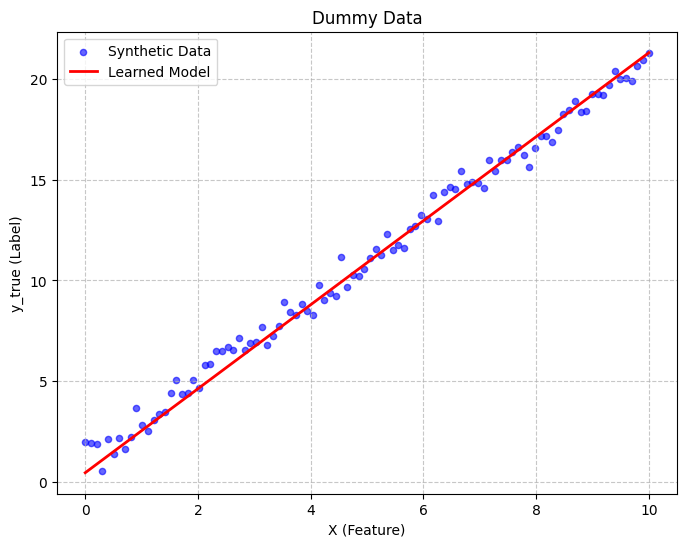

In [7]:
# 실제 데이터와 회귀선 비교
def show_data(X, y_true):
    X_np = X.squeeze().numpy()
    y_true_np = y_true.squeeze().numpy()
    w_learned = model.weight.item()
    b_learned = model.bias.item()
    print(w_learned, b_learned)
    y_line_np = w_learned * X_np + b_learned

    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 6))
    plt.scatter(X_np, y_true_np, s=20, color='b', alpha=0.6, label='Synthetic Data')
    plt.plot(X_np, y_line_np, color='red', linewidth=2, label=f'Learned Model')

    plt.title('Dummy Data')
    plt.xlabel('X (Feature)')
    plt.ylabel('y_true (Label)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
show_data(X, y_true)

In [8]:
import torch
from torch import nn


class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


class SequentialMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()

        # 각 층을 순차적으로 쌓는다.
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.layers(x)


model = SimpleMLP(20, 10, 1)


X = torch.ones(size=(40, 20))
y_pred = model(X)
print(y_pred.size())
y_pred



torch.Size([40, 1])


tensor([[-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150],
        [-0.2150]], grad_fn=<AddmmBackward0>)

In [9]:
from typing import Tuple

class MLP(nn.Module):
    def __init__(self,
                 input_dim: int,
                 num_classes: int,
                 hidden_dims: Tuple[int] = (128, 64),
                 dropout: float = 0.2):
        super().__init__()
        h1, h2 = hidden_dims
        # forward가 동작되도록 여기에 구현해주세요.
        self.net = None

    def forward(self, x):
        return self.net(x)

In [10]:
def train_one_epoch(model, loader, optimizer, device):
    running_loss = 0.0
    correct = 0
    total = 0

    # 1. 모델이 학습모드로 들어가게 설정해야합니다.
    model.train()

    # 2. 위에서 배운 파라미터 업데이트 방식을 구현해주세요:
    for xb, yb in loader:
        # 2.1 데이터를 가속화기기로 보내주세요.
        xb, yb = xb.to(device), yb.to(device)

        # 2.2 모델의 출력 만들어주기
        logits = model(xb)

        # 2.3 미분값 지워주기 (`zero_grad`)
        optimizer.zero_grad()

        # 2.4 `torch.nn.functional.cross_entropy`를 통해 `loss` 계산해주기
        loss = torch.nn.functional.cross_entropy(logits, yb)

        # 2.5 `loss`를 기준으로 역전파를 수행합니다.
        loss.backward()

        # 2.6 파라미터 업데이트를 진행해주세요
        optimizer.step()

        # 파라미터 업데이트가 끝났으면 몇 가지를 기록해줍니다.
        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    # 위에서 잘 계산된 값들을 정리해서 반환합니다.
    avg_loss = running_loss / total
    acc = correct / total
    return avg_loss, acc 